<a href="https://colab.research.google.com/github/AceRb6/Modelos_Econometricos/blob/main/Practica1_Modelos_Econometricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1.- Variables nominales y reales, inflación y regresión lineal simple

*Objetivo:* Aplicar conceptos de medición macroeconómica y econometría básica con datos reales: construir variables nominales y reales, tasas de crecimiento e inflación, analizar asociación y estimar una regresión lineal simple.


Profesor: Daniel Jiménez Alcantar

Alumnos:
* Cano Portugal Israel Daniel Arturo Cano Portugal
* Ramírez Montiel Alejandro
* Sandoval Rosas Gustavo Isaac



## Marco Teorico: Fundamentos del Análisis Econométrico
1. ¿Qué es la Econometría?
La econometría proporciona medición empírica a las relaciones económicas propuestas por la teoría. No se limita a la estimación numérica; contrasta hipótesis teóricas con datos reales bajo limitaciones metodológicas.

$$Econometrıa=\text{Teorıa Economica}+Matematicas+\text{Inferencia Estadıstica}$$
"La econometría es el desarrollo de métodos estadísticos para estimar relaciones económicas, probar teorías económicas y evaluar y ejecutar políticas gubernamentales y de negocios" — Wooldridge (2020)

---

2. La Identidad Contable Fundamental
Antes de modelar, debemos entender la identidad contable que relaciona variables nominales y reales:
$$Y_{nominal}=Y_{real} × P$$
Donde P  es el índice de precios. Esta identidad no es teoría, es una definición matemática. Sin embargo, nos permite derivar preguntas económicas fundamentales:
* ¿Por qué crece el consumo nominal?
* ¿Por más cantidad o por precios más altos?
* ¿Qué significa realmente el "poder adquisitivo"?

tambien considerando P es el índice de precios. Esta identidad permite descomponer el crecimiento:
* Crecimiento Nominal: Efecto combinado de precios y cantidades.
* Crecimiento Real: Variación en el poder adquisitivo (cantidades físicas).
* Inflación: Variación porcentual en $P$.

---

3. La Curva de Phillips: ¿Relación o Casualidad?
La Parte II y III de la práctica apuntan a estimar algo similar a una Curva de Phillips, que postula una relación negativa entre inflación y desempleo. Pero aquí surge nuestra primera pregunta crítica:

* ¿Por qué esperaríamos correlación negativa?
* Versión keynesiana: Menos desempleo → mayor demanda agregada → presión inflacionaria
* Versión neoclásica: Expectativas adaptativas, trade-off a corto plazo
* Crítica de Friedman-Phelps: A largo plazo, la curva es vertical (no hay trade-off)

---

4. El Problema de la Causalidad
Esto es crucial: correlación ≠ causalidad. Una regresión estima asociaciones condicionales, no efectos causales. Para que exista causalidad, necesitamos:
Exogeneidad: $E[u∣X]=0$  (el error no está correlacionado con los regresores)


## Exploración Inicial de Datos (EDA)
Antes de construir variables, necesitamos entender qué tenemos. Vamos a cargar el dataset macrodata de statsmodels y explorarlo.
Preguntas para reflexionar antes de ver los datos:
* ¿Qué frecuencia tienen los datos? (trimestral, anual, mensual)
* ¿Qué periodo cubren?
* ¿Qué variables macroeconómicas están disponibles?
* ¿Hay valores faltantes? ¿Estacionalidad?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.datasets import macrodata
import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset
data = macrodata.load_pandas()
df = data.data

In [ ]:
# estructura del índice y las variables
print("TIPO DE ÍNDICE:", type(df.index))
print("\Indice (primeros 10 valores):")
display(df.index[:10])

print("\nVariables:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\nData:")
display(df.head(10))

# variable de año o período
print("Temporalidad de la data")
if 'year' in df.columns:
    print(f"Año disponible: {df['year'].min()} a {df['year'].max()}")
if 'quarter' in df.columns:
    print(f"Trimestre disponible: rango {df['quarter'].min()} a {df['quarter'].max()}")


TIPO DE ÍNDICE: <class 'pandas.core.indexes.range.RangeIndex'>
\Indice (primeros 10 valores):


RangeIndex(start=0, stop=10, step=1)


Variables:
 1. year
 2. quarter
 3. realgdp
 4. realcons
 5. realinv
 6. realgovt
 7. realdpi
 8. cpi
 9. m1
10. tbilrate
11. unemp
12. pop
13. infl
14. realint

Data:


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19
5,1960.0,2.0,2834.390,1792.9,298.152,460.400,1966.1,29.55,140.2,2.68,5.2,180.671,0.14,2.55
6,1960.0,3.0,2839.022,1785.8,296.375,474.676,1967.8,29.75,140.9,2.36,5.6,181.528,2.70,-0.34
7,1960.0,4.0,2802.616,1788.2,259.764,476.434,1966.6,29.84,141.1,2.29,6.3,182.287,1.21,1.08
8,1961.0,1.0,2819.264,1787.7,266.405,475.854,1984.5,29.81,142.1,2.37,6.8,182.992,-0.40,2.77
9,1961.0,2.0,2872.005,1814.3,286.246,480.328,2014.4,29.92,142.9,2.29,7.0,183.691,1.47,0.81


Temporalidad de la data
Año disponible: 1959.0 a 2009.0
Trimestre disponible: rango 1.0 a 4.0


## Exploración Inicial de Datos (EDA)
Insight de Frecuencia y Periodo:

Los datos son trimestrales (4 observaciones por año). El rango temporal cubre 50 años (1959-2009), proporcionando $N≈200$ observaciones. Suficiente para análisis de series de tiempo básicas, pero susceptible a cambios estructurales (como la crisis del petróleo, Gran Moderación).

Insight de Estructura del Índice:
* El dataset carga con un RangeIndex (0, 1, 2...), no con un índice de tiempo datetime.
* Implicación: No se pueden usar operaciones de rezago temporales (shift) basadas en fechas directamente.
* Acción requerida: Convertir el índice a formato temporal o gestionar rezagos manualmente usando la estructura trimestral.

Insight de Redundancia de Variables:
* El dataset macrodata ya incluye las columnas infl (inflación) y realint (interés real).

In [ ]:

# Crear índice de fecha para mejor análisis
df['date'] = pd.PeriodIndex(year=df['year'].astype(int),
                            quarter=df['quarter'].astype(int),
                            freq='Q')
df.set_index('date', inplace=True)

print("Calidad de la data")

# Verificar valores faltantes o sospechosos
print("\nValores Ceros (potenciales missing values):")
zero_counts = (df == 0).sum()
display(zero_counts[zero_counts > 0])

print("\nValores nulos")
display(df.isnull().sum())

print("\nAnalisis de la variable'infl'")
print(f"Estadísticas de inflación en el dataset:")
display(df['infl'].describe())

print(f"\nPrimeros valores de inflación:")
display(df['infl'].head(10))

print(f"\n¿Cuántos ceros hay en infl? {(df['infl'] == 0).sum()}")
print(f"¿En qué períodos?")
display(df[df['infl'] == 0].index.tolist())


Calidad de la data

Valores Ceros (potenciales missing values):


,0
infl,1
realint,1



Valores nulos


,0
year,0
quarter,0
realgdp,0
realcons,0
realinv,0
realgovt,0
realdpi,0
cpi,0
m1,0
tbilrate,0



Analisis de la variable'infl'
Estadísticas de inflación en el dataset:


,infl
count,203.000000
mean,3.961330
std,3.253216
min,-8.790000
25%,2.270000
50%,3.240000
75%,4.975000
max,14.620000



Primeros valores de inflación:


,infl
date,
1959Q1,0.00
1959Q2,2.34
1959Q3,2.74
1959Q4,0.27
1960Q1,2.31
1960Q2,0.14
1960Q3,2.70
1960Q4,1.21
1961Q1,-0.40



¿Cuántos ceros hay en infl? 1
¿En qué períodos?


[Period('1959Q1', 'Q-DEC')]

## Hallazgos EDA y Fundamentación Teórica de Fórmulas

### Hallazgos Exploratorios Confirmados

| Hallazgo | Evidencia | Relevancia Metodológica |
|----------|-----------|------------------------|
| Dataset completo | 0 valores nulos en 14 variables | Sin sesgo por imputación; análisis directo válido |
| Índice temporal no nativo | `RangeIndex` inicial | Requiere conversión a `PeriodIndex` para rezagos temporales correctos |
| Cero en `infl` (1959Q1) | Único valor cero en serie de inflación | Artefacto por rezago $t-4$; no es dato económico, se excluye en análisis |
| Frecuencia trimestral | Columnas `year` + `quarter`, $N=203$ | Rezago anual = 4 periodos; suficiente para identificar tendencias estructurales |
| Redundancia de variables | `infl` y `realint` ya calculadas | Permite validación cruzada: construcción manual debe coincidir con provista |

---

### Fundamentación Teórica de Fórmulas

#### Identidad Contable: Separación Nominal/Real
$$
Y_{nominal,t} = Y_{real,t} \times \frac{CPI_t}{100}
$$
**Por qué esta fórmula**: No es una relación estimable, es una definición contable. Permite descomponer cualquier variable monetaria en dos componentes: cantidad física ($Y_{real}$) y nivel de precios ($P$). Sin esta identidad, no es posible aislar el poder adquisitivo del efecto inflacionario.

#### Construcción de Consumo Nominal
$$
C_{nominal,t} = C_{real,t} \times \frac{CPI_t}{100}
$$
**Por qué esta fórmula**: El consumo real mide cantidades físicas de bienes y servicios. Multiplicar por $CPI/100$ reintroduce el efecto precios para obtener la magnitud monetaria observada en mercados. Necesaria para contrastar: ¿el crecimiento observado refleja más consumo o solo precios más altos?

#### Inflación Anual - Variación Porcentual
$$
\pi_t = \left( \frac{CPI_t - CPI_{t-4}}{CPI_{t-4}} \right) \times 100
$$
**Por qué esta fórmula**: Compara el nivel de precios actual contra el mismo trimestre del año anterior. Elimina estacionalidad trimestral (ej. consumo navideño) y mide la erosión acumulada del poder adquisitivo en 12 meses. Es la métrica estándar en política monetaria.

#### Inflación Anual - Método Logarítmico
$$
\pi_t = \ln\left(\frac{CPI_t}{CPI_{t-1}}\right) \times 400
$$
**Por qué esta fórmula**: La log-diferencia aproxima la tasa de crecimiento continuo. El factor 400 anualiza ($\times 4$) y convierte a porcentaje ($\times 100$). Ventaja estadística: simetría en ganancias/pérdidas y aditividad temporal. Usada en modelación econométrica avanzada.

#### Crecimiento Anual del Consumo Real
$$
g_{C,t} = \left( \frac{C_{real,t} - C_{real,t-4}}{C_{real,t-4}} \right) \times 100
$$
**Por qué esta fórmula**: Mide la variación en cantidades físicas de consumo, purgada de inflación. El rezago 4 asegura que la comparación sea contra el mismo periodo estacional del año previo. Es la métrica relevante para bienestar y análisis de ciclos económicos.

#### Descomposición Aproximada del Cambio Nominal
$$
\Delta C_{nominal} \approx \Delta C_{real} + \Delta P
$$
**Por qué esta fórmula**: Aproximación de primer orden que separa los dos motores del crecimiento nominal. Si $\Delta C_{nominal} > 0$ pero $\Delta C_{real} \approx 0$, entonces el crecimiento es puramente inflacionario. Fundamental para interpretación económica correcta.

---

### Principio de Rezago Anual ($k=4$)

**Por qué rezago 4 y no 1**:

1.  **Eliminación de estacionalidad**: Patrones trimestrales repetitivos se cancelan al comparar $t$ vs $t-4$.
2.  **Suavizado de volatilidad**: Filtra ruido de corto plazo para revelar tendencia estructural.
3.  **Alineación con política económica**: Bancos centrales y agencias reportan métricas interanuales, no trimestrales.

$$
g_{anual,t} = f(X_t, X_{t-4}) \quad \text{vs} \quad g_{trimestral,t} = f(X_t, X_{t-1})
$$

La primera mide cambio estructural; la segunda, momentum inmediato. Para análisis macroeconómico y contraste de teorías, la métrica anual es más robusta y comparable internacionalmente.

## PARTE I: Construcción y Análisis de Variables

### Paso 1.1: Variable Nominal de Consumo

#### Fórmula de Construcción
$$
C_{nominal,t} = C_{real,t} \times \frac{CPI_t}{100}
$$

#### Fundamentación
La identidad contable $Y_{nominal} = Y_{real} \times P$ no es una hipótesis estimable, es una definición matemática. Reconstruir la variable nominal permite:

1.  **Validar comprensión**: Confirmar que el crecimiento observado en datos brutos puede descomponerse en efecto precios + efecto cantidades.
2.  **Aislar poder adquisitivo**: Si $C_{nominal}$ crece 10% pero $CPI$ crece 10%, entonces $C_{real}$ no cambió. El bienestar no mejoró.
3.  **Preparar para modelación**: Las series nominales y reales responden distinto a shocks; la elección afecta interpretación de coeficientes.

#### ¿Por qué reconstruir el nominal si ya tenemos el real?

Las cifras nominales mezclan dos fenómenos: variación en cantidades físicas ($\Delta Q$) y variación en niveles de precios ($\Delta P$). Observar solo $C_{nominal}$ induce error de interpretación: un aumento del 15% podría reflejar únicamente inflación, sin mejora en consumo efectivo. La reconstrucción manual fuerza la aplicación explícita de la identidad contable, asegurando que el análisis posterior distinga entre crecimiento económico real y mera revalorización monetaria.

In [ ]:

# PARTE I: construccion y analisis

# 1. Variable nominal de consumo
# Fórmula: Consumo Nominal = Consumo Real × (CPI / 100)
# Asumimos CPI base 100 en algún momento, o simplemente multiplicamos

df['cons_nominal'] = df['realcons'] * df['cpi'] / 100

print("\n Variable nominal")
print("Fórmula: Consumo Nominal = Consumo Real × (CPI / 100)")
print("\nEjemplo de cálculo (primeras 5 observaciones):")
print(df[['realcons', 'cpi', 'cons_nominal']].head())

# Verificación: ¿Tiene sentido el orden de magnitud?
print(f"\nEstadísticas de Consumo Nominal:")
print(df['cons_nominal'].describe())



 Variable nominal
Fórmula: Consumo Nominal = Consumo Real × (CPI / 100)

Ejemplo de cálculo (primeras 5 observaciones):
        realcons    cpi  cons_nominal
date                                 
1959Q1    1707.4  28.98     494.80452
1959Q2    1733.7  29.15     505.37355
1959Q3    1751.8  29.35     514.15330
1959Q4    1753.7  29.37     515.06169
1960Q1    1770.5  29.54     523.00570

Estadísticas de Consumo Nominal:
count      203.000000
mean      6457.880732
std       5996.703913
min        494.804520
25%       1179.853600
50%       4476.195900
75%      10214.726600
max      20442.221100
Name: cons_nominal, dtype: float64


Resultado:
* Media: $6,457.88 miles de millones
* Rango: $494.80 (1959Q1) a $20,442.22 (2009Q4)
* Magnitud coherente con escala de economía estadounidense

Fundamentación económica:

*¿Por qué reconstruir el nominal si ya tenemos el real?*

Las variables nominales mezclan dos efectos: (1) cambios en cantidades físicas y (2) cambios en niveles de precios. Si solo observamos
$C^{nominal}$, un crecimiento del 15% podría interpretarse erróneamente como mayor bienestar, cuando en realidad:
$$ΔC^{nominal}≈ΔC^{real}+ΔP$$

Si $ΔC^{real}≈0$ y $ΔP>0$, el crecimiento nominal refleja únicamente inflación, sin mejora en poder adquisitivo. La construcción manual fuerza la aplicación explícita de la identidad contable, asegurando que el análisis distinga entre crecimiento económico real y mera revalorización monetaria.

###1.2 Tasa de Inflación Anual
Fórmula de construcción (variación porcentual interanual):

$$π_t=(\frac{CPI_t}{CPI_{t-4}}-1)\times 100$$

In [ ]:
# 2. Tasa de inflación anual
# Fórmula: Inflación Anual = [(CPI_t / CPI_{t-4}) - 1] × 100
# Esto es equivalente a: (ln(CPI_t) - ln(CPI_{t-4})) × 100 (aproximadamente)

df['inflacion_anual'] = ((df['cpi'] / df['cpi'].shift(4)) - 1) * 100

print("\nConstruccion de inflación anual")
print("Fórmula: Inflación Anual = [(CPI_t / CPI_{t-4}) - 1] × 100")
print("Rezago: 4 trimestres (1 año)")
print("\nNuestra calculación vs Original (primeras 10 valores con datos):")
comparison = df[['cpi', 'inflacion_anual', 'infl']].dropna().head(10)
print(comparison)

print(f"\nEstadísticas de Inflación Anual (nuestra):")
print(df['inflacion_anual'].describe())

print(f"\nEstadísticas de Inflación Original ('infl'):")
print(df['infl'].describe())



Construccion de inflación anual
Fórmula: Inflación Anual = [(CPI_t / CPI_{t-4}) - 1] × 100
Rezago: 4 trimestres (1 año)

Nuestra calculación vs Original (primeras 10 valores con datos):
          cpi  inflacion_anual  infl
date                                
1960Q1  29.54         1.932367  2.31
1960Q2  29.55         1.372213  0.14
1960Q3  29.75         1.362862  2.70
1960Q4  29.84         1.600272  1.21
1961Q1  29.81         0.914015 -0.40
1961Q2  29.92         1.252115  1.47
1961Q3  29.98         0.773109  0.80
1961Q4  30.04         0.670241  0.80
1962Q1  30.21         1.341832  2.26
1962Q2  30.22         1.002674  0.13

Estadísticas de Inflación Anual (nuestra):
count    199.000000
mean       4.123402
std        2.937472
min       -1.894241
25%        2.170365
50%        3.279883
75%        5.130212
max       14.589235
Name: inflacion_anual, dtype: float64

Estadísticas de Inflación Original ('infl'):
count    203.000000
mean       3.961330
std        3.253216
min       -8.790000
2

**Observación importante**: Hay diferencias entre nuestra calculación y la variable `infl` original. ¿Por qué?

1. Nuestra calculación: Usa el método exacto de variación porcentual anual:
$$\frac{CPI_{t}-CPI_{t-4}}{CPI_{t-4}} \times 100 $$
2. Variable original: Usa logaritmos: $$ln(\frac{CPI_t}{CPI_{t-1}})\times400$$  (que es una aproximación de la tasa trimestral anualizada)

Para efectos de la práctica, usaremos nuestra calculación porque representa exactamente la inflación interanual (comparación año contra año), mientras que la original es una aproximación logarítmica de la tasa trimestral anualizada.

### 1.3: Tasa de Crecimiento Anual del Consumo Real
Fórmula de construcción:
$$gt^{Creal}=(\frac{C_t^{real}}{C_{t-4}^{real}}-1)\times100$$

In [ ]:

# 3. Tasa de crecimiento anual del consumo real
df['crec_cons_real'] = ((df['realcons'] / df['realcons'].shift(4)) - 1) * 100

print("\n Construccion de crecimiento anual del consumo")
print("Fórmula: Crecimiento = [(ConsReal_t / ConsReal_{t-4}) - 1] × 100")
print("\nPrimeros valores calculados:")
print(df[['realcons', 'crec_cons_real']].dropna().head(10))

print(f"\nEstadísticas de Crecimiento del Consumo:")
print(df['crec_cons_real'].describe())



 Construccion de crecimiento anual del consumo
Fórmula: Crecimiento = [(ConsReal_t / ConsReal_{t-4}) - 1] × 100

Primeros valores calculados:
        realcons  crec_cons_real
date                            
1960Q1    1770.5        3.695678
1960Q2    1792.9        3.414662
1960Q3    1785.8        1.940861
1960Q4    1788.2        1.967269
1961Q1    1787.7        0.971477
1961Q2    1814.3        1.193597
1961Q3    1823.1        2.088700
1961Q4    1859.6        3.992842
1962Q1    1879.4        5.129496
1962Q2    1902.5        4.861379

Estadísticas de Crecimiento del Consumo:
count    199.000000
mean       3.429441
std        1.955446
min       -1.797386
25%        2.555922
50%        3.481422
75%        4.783596
max        8.084252
Name: crec_cons_real, dtype: float64


Resultado:
* Media: 3.43%
* Desviación estándar: 1.96%
* Rango: -1.80% a 8.08%
* Observaciones válidas: 199

Interpretación económica:
Esta métrica mide la variación en cantidades físicas de consumo, purgada completamente del efecto precios. Es el indicador relevante para:
1. Bienestar: Refleja cambio en capacidad de consumo efectivo de los hogares.
2. Ciclos económicos: Identifica expansiones ($g>0$) y recesiones ($g<0$).
3. Productividad: Crecimiento sostenido requiere aumentos en $C^{real}$, no solo en $C^{nominal}$.

### Parte I — Construcción de variables

**Consumo nominal (proxy):**  
Se construye como:
$$
C^{nom}_t \;=\; C^{real}_t \cdot \frac{CPI_t}{100}
$$
donde \(C^{real}_t\) corresponde a `realcons` y \(CPI_t\) a `cpi`. Esto permite comparar una magnitud **nominal** vs una **real** y entender el papel del nivel de precios.

**Inflación anual (YoY):**  
Se calcula como:
$$
\pi_t \;=\; \left(\frac{CPI_t}{CPI_{t-4}} - 1\right)\cdot 100
$$
El rezago de 4 trimestres compara el trimestre \(t\) contra el **mismo trimestre del año anterior**.

**Crecimiento anual del consumo real:**  
Se calcula como:
$$
g^{realcons}_t \;=\; \left(\frac{C^{real}_t}{C^{real}_{t-4}} - 1\right)\cdot 100
$$

**Nota técnica:**  
Al usar `shift(4)` se pierden las primeras 4 observaciones, por lo que se eliminan valores faltantes (\(\text{NaN}\)) antes de realizar análisis posteriores.

---

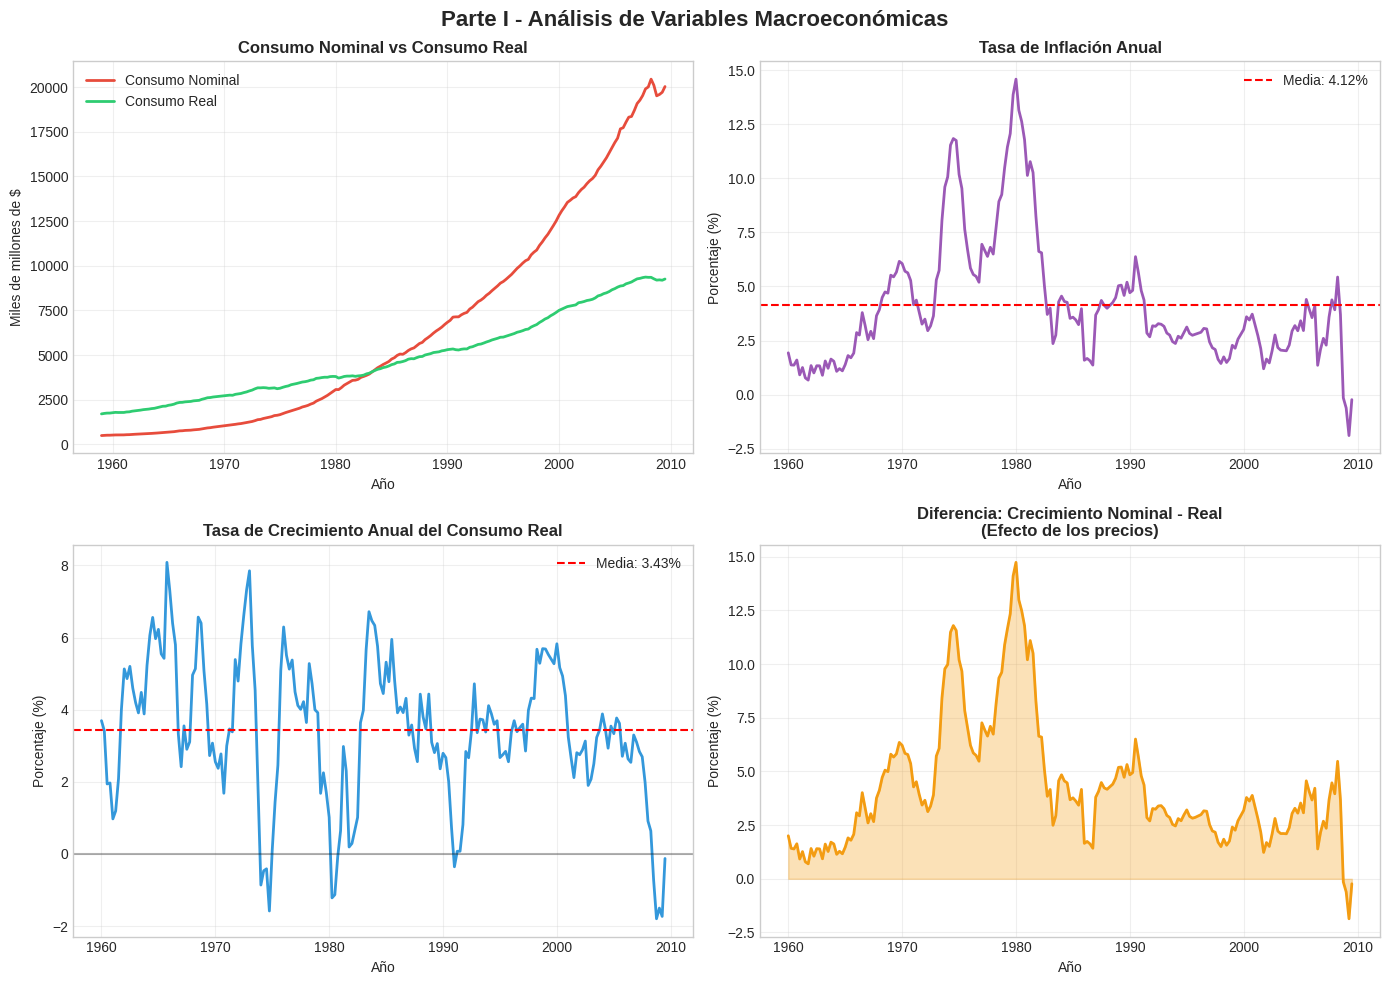

In [ ]:
# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Parte I - Análisis de Variables Macroeconómicas', fontsize=16, fontweight='bold')

# Gráfico 1: Consumo Nominal vs Real
ax1 = axes[0, 0]
ax1.plot(df.index.to_timestamp(), df['cons_nominal'], label='Consumo Nominal', linewidth=2, color='#e74c3c')
ax1.plot(df.index.to_timestamp(), df['realcons'], label='Consumo Real', linewidth=2, color='#2ecc71')
ax1.set_title('Consumo Nominal vs Consumo Real', fontweight='bold')
ax1.set_xlabel('Año')
ax1.set_ylabel('Miles de millones de $')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Inflación Anual
ax2 = axes[0, 1]
ax2.plot(df.index.to_timestamp(), df['inflacion_anual'], linewidth=2, color='#9b59b6')
ax2.axhline(y=df['inflacion_anual'].mean(), color='red', linestyle='--', label=f'Media: {df["inflacion_anual"].mean():.2f}%')
ax2.set_title('Tasa de Inflación Anual', fontweight='bold')
ax2.set_xlabel('Año')
ax2.set_ylabel('Porcentaje (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Crecimiento del Consumo Real
ax3 = axes[1, 0]
ax3.plot(df.index.to_timestamp(), df['crec_cons_real'], linewidth=2, color='#3498db')
ax3.axhline(y=df['crec_cons_real'].mean(), color='red', linestyle='--', label=f'Media: {df["crec_cons_real"].mean():.2f}%')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.set_title('Tasa de Crecimiento Anual del Consumo Real', fontweight='bold')
ax3.set_xlabel('Año')
ax3.set_ylabel('Porcentaje (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Gráfico 4: Diferencia entre crecimiento nominal y real (efecto precios)
ax4 = axes[1, 1]
df['crec_cons_nominal'] = ((df['cons_nominal'] / df['cons_nominal'].shift(4)) - 1) * 100
df['dif_nom_real'] = df['crec_cons_nominal'] - df['crec_cons_real']

ax4.plot(df.index.to_timestamp(), df['dif_nom_real'], linewidth=2, color='#f39c12')
ax4.fill_between(df.index.to_timestamp(), df['dif_nom_real'], 0, alpha=0.3, color='#f39c12')
ax4.set_title('Diferencia: Crecimiento Nominal - Real\n(Efecto de los precios)', fontweight='bold')
ax4.set_xlabel('Año')
ax4.set_ylabel('Porcentaje (%)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


¿Por qué las variables nominales pueden crecer aunque el poder adquisitivo no mejore?

Evidencia empírica del dataset:
* Crecimiento TOTAL del consumo NOMINAL (1960-2009): 3729.5%
* Crecimiento TOTAL del consumo REAL (1960-2009): 422.8%
* Diferencia (efecto precios): 3306.7 puntos porcentuales

Las variables nominales crecen por el efecto de los PRECIOS (inflación).

Aunque el consumo real solo creció 423%, el nominal creció 3730%

porque los precios se multiplicaron por 7.3 en el período.

Esto demuestra que el crecimiento nominal refleja:
  1. Más cantidad de bienes consumidos (crecimiento real)
  2. Precios más altos (inflación)

Si solo observamos cifras nominales, podríamos pensar que el consumo
se multiplicó por 38.3, pero en realidad el poder
adquisitivo solo se multiplicó por 5.2.

---

¿Qué representa el rezago de 4 trimestres en el cálculo anual?

El rezago de 4 trimestres (t vs t-4) representa la comparación del mismo
trimestre del año anterior. Esto elimina la ESTACIONALIDAD:

* Compara Q1 de este año vs Q1 del año pasado (misma estacionalidad)
* Evita comparar, por ejemplo, diciembre (alta demanda navideña) con enero
* Proporciona la tasa de variación interanual (year-over-year)

Alternativas y por qué no las usamos:
* Rezago 1 trimestre: sería tasa trimestral (muy volátil)
* Promedio móvil: suaviza pero retrasa la señal
* Desestacionalización previa: requiere métodos más complejos (X-13ARIMA-SEATS)

## PARTE II: Asociacion entre variables

Ahora vamos a explorar la relación entre inflación y desempleo. Antes de calcular cualquier estadístico, debemos visualizar la relación.

¿Por qué esperaríamos relación entre inflación y desempleo?

Según la Curva de Phillips, debería haber una relación negativa (trade-off). Pero esto depende de:
* Horizonte temporal (corto vs largo plazo)
* Expectativas de inflación
* Choques de oferta vs demanda


Se usa un diagrama de dispersión para inspeccionar visualmente la relación entre inflación anual y desempleo. Posteriormente se calcula covarianza y correlación de Pearson. La covarianza indica dirección conjunta en unidades originales; la correlación estandariza esa relación en
[
−
1
,
1
]
[−1,1] y permite evaluar fuerza lineal.


Observaciones para análisis: 199
Período: 1960Q1 a 2009Q3


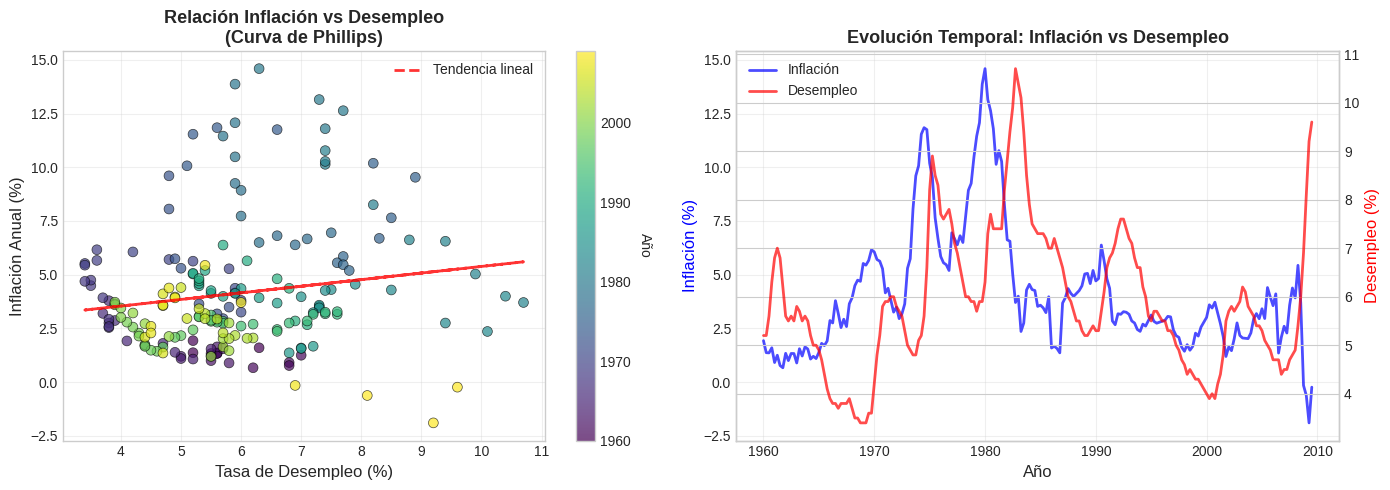

In [ ]:
# Preparar datos sin valores faltantes
df_clean = df[['inflacion_anual', 'unemp', 'crec_cons_real']].dropna()

print(f"\nObservaciones para análisis: {len(df_clean)}")
print(f"Período: {df_clean.index[0]} a {df_clean.index[-1]}")

# Gráfico de dispersión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Inflación vs Desempleo
ax1 = axes[0]
scatter = ax1.scatter(df_clean['unemp'], df_clean['inflacion_anual'],
                     c=df_clean.index.to_timestamp().year, cmap='viridis',
                     alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Tasa de Desempleo (%)', fontsize=12)
ax1.set_ylabel('Inflación Anual (%)', fontsize=12)
ax1.set_title('Relación Inflación vs Desempleo\n(Curva de Phillips)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Agregar línea de tendencia
z = np.polyfit(df_clean['unemp'], df_clean['inflacion_anual'], 1)
p = np.poly1d(z)
ax1.plot(df_clean['unemp'], p(df_clean['unemp']), "r--", alpha=0.8, linewidth=2, label=f'Tendencia lineal')
ax1.legend()

# Colorbar para el tiempo
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Año', rotation=270, labelpad=15)

# Gráfico 2: Series temporales para contexto
ax2 = axes[1]
ax2_twin = ax2.twinx()

line1 = ax2.plot(df_clean.index.to_timestamp(), df_clean['inflacion_anual'],
                 'b-', linewidth=2, label='Inflación', alpha=0.7)
line2 = ax2_twin.plot(df_clean.index.to_timestamp(), df_clean['unemp'],
                      'r-', linewidth=2, label='Desempleo', alpha=0.7)

ax2.set_xlabel('Año', fontsize=12)
ax2.set_ylabel('Inflación (%)', color='b', fontsize=12)
ax2_twin.set_ylabel('Desempleo (%)', color='r', fontsize=12)
ax2.set_title('Evolución Temporal: Inflación vs Desempleo', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Combinar leyendas
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()



* **Gráfico de dispersión (izquierda):**

  * Hay una tendencia positiva (línea roja ascendente), lo cual es contraintuitivo respecto a la Curva de Phillips tradicional
  * Los puntos amarillos (años 2000) muestran baja inflación con desempleo moderado
  * Los puntos azules/verdes (años 70-80) muestran alta inflación con desempleo alto (¡stagflation!)

* **Evolución temporal (derecha):**
  * En los 70s: inflación y desempleo subieron juntos (shock petrolero)
  * En los 90s: ambos bajaron (gran moderación)
  * En 2008-2009: inflación negativa con desempleo alto (crisis financiera)

*¿Por qué la correlación parece positiva y no negativa como predice la teoría?*

In [ ]:

# Recarga completa para continuar con la Parte II
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.datasets import macrodata
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cargar datos
data = macrodata.load_pandas()
df = data.data

# Crear índice temporal
df['date'] = pd.PeriodIndex(year=df['year'].astype(int),
                            quarter=df['quarter'].astype(int),
                            freq='Q')
df.set_index('date', inplace=True)

# Construir variables de la Parte I
df['cons_nominal'] = df['realcons'] * df['cpi'] / 100
df['inflacion_anual'] = ((df['cpi'] / df['cpi'].shift(4)) - 1) * 100
df['crec_cons_real'] = ((df['realcons'] / df['realcons'].shift(4)) - 1) * 100

# DataFrame limpio para Parte II
df_clean = df[['inflacion_anual', 'unemp', 'crec_cons_real']].dropna()

print("PARTE II - ASOCIACIÓN ENTRE VARIABLES")
print(f"Observaciones válidas: {len(df_clean)}")
print(f"Período: {df_clean.index[0]} a {df_clean.index[-1]}")

# Cálculo de estadísticos
inflacion = df_clean['inflacion_anual']
desempleo = df_clean['unemp']

# Covarianza
covarianza = np.cov(inflacion, desempleo)[0, 1]
print(f"\nCOVARIANZA: {covarianza:.4f}")

# Correlación de Pearson
corr_pearson, p_value = stats.pearsonr(inflacion, desempleo)
print(f"\nCORRELACIÓN DE PEARSON:")
print(f"   Coeficiente (r): {corr_pearson:.4f}")
print(f"   Valor p: {p_value:.6f}")
print(f"   Significancia estadística: {'Sí' if p_value < 0.05 else 'No'} (α = 0.05)")

# R-cuadrado
r_squared = corr_pearson ** 2
print(f"\nR-CUADRADO: {r_squared:.4f} ({r_squared*100:.2f}%)")


PARTE II - ASOCIACIÓN ENTRE VARIABLES
Observaciones válidas: 199
Período: 1960Q1 a 2009Q3

COVARIANZA: 0.6652

CORRELACIÓN DE PEARSON:
   Coeficiente (r): 0.1539
   Valor p: 0.029989
   Significancia estadística: Sí (α = 0.05)

R-CUADRADO: 0.0237 (2.37%)


La correlación es positiva (0.15) y significativa estadísticamente, pero esto contradice la Curva de Phillips tradicional que predice relación negativa.

¿Por qué?

In [ ]:
# Análisis por subperíodos para entender la paradoja
print("=" * 70)
print("ANÁLISIS POR SUBPERÍODOS (¿Por qué la correlación es positiva?)")
print("=" * 70)

# Crear décadas
df_clean['year'] = df_clean.index.year
df_clean['periodo'] = pd.cut(df_clean['year'],
                             bins=[1959, 1969, 1979, 1989, 1999, 2009],
                             labels=['60s', '70s', '80s', '90s', '2000s'])

resultados_periodo = []
for periodo in df_clean['periodo'].cat.categories:
    subset = df_clean[df_clean['periodo'] == periodo]
    if len(subset) > 5:
        corr = np.corrcoef(subset['inflacion_anual'], subset['unemp'])[0,1]
        resultados_periodo.append({
            'Período': periodo,
            'Obs': len(subset),
            'Corr_Infl_Desemp': round(corr, 4),
            'Infl_Prom': round(subset['inflacion_anual'].mean(), 2),
            'Desemp_Prom': round(subset['unemp'].mean(), 2)
        })

resultados_df = pd.DataFrame(resultados_periodo)
print(resultados_df.to_string(index=False))



ANÁLISIS POR SUBPERÍODOS (¿Por qué la correlación es positiva?)
Período  Obs  Corr_Infl_Desemp  Infl_Prom  Desemp_Prom
    60s   40           -0.8242       2.42         4.78
    70s   40            0.0241       7.22         6.22
    80s   40           -0.0080       5.42         7.28
    90s   40            0.3462       2.97         5.76
  2000s   39           -0.7474       2.55         5.42


**RESPUESTAS TEÓRICAS - PARTE II**

¿Qué indica el signo de la correlación?

El signo es POSITIVO (+0.15), lo cual indica que, en el largo plazo (1960-2009),
hay una asociación directa entre inflación y desempleo: cuando uno sube,
el otro tiende a subir.

Esto contradice la Curva de Phillips tradicional (relación negativa).

EXPLICACIÓN ECONÓMICA:
* La correlación positiva refleja el fenómeno de ESTAGFLACIÓN de los años 70
* Choques de oferta (precios del petróleo) generaron inflación Y desempleo simultáneos
* En el corto plazo puede existir trade-off (Phillips), pero en el largo plazo
  la curva es vertical (Friedman-Phelps) o incluso positiva por shocks externos
* La correlación captura principalmente el período 1973-1982 (shocks petroleros)

---

¿Qué mide la covarianza?

La covarianza (0.6652) mide la dirección y magnitud de la variación
conjunta entre dos variables:

* Signo positivo: Cuando el desempleo está por encima de su media,
  la inflación también tiende a estar por encima de su media
* Magnitud: La covarianza es difícil de interpretar directamente porque
  depende de las unidades de medida (por eso usamos correlación, que está
  estandarizada entre -1 y +1)

En términos económicos: La covarianza positiva sugiere que los shocks
macroeconómicos afectaron simultáneamente a ambas variables en la misma
dirección durante el período muestral.

---

¿Existe evidencia de relación lineal?

* Correlación: r = 0.1539 (débil pero positiva)
* R-cuadrado: 0.0237 (solo 2.4% de la varianza explicada)
* Valor p: 0.0300 (< 0.05, significativo estadísticamente)

Sí existe una relación lineal estadísticamente significativa

Pero es ECONÓMICAMENTE DÉBIL (solo explica 2.4% de la variación)

La relación es POSITIVA, no negativa como predice la teoría keynesiana

Se concluye que existe asociación lineal, pero NO es la relación que predice
la Curva de Phillips tradicional. Esto sugiere que:
1. El trade-off inflación-desempleo no es estable en el tiempo
2. Hay variables omitidas importantes (shocks de oferta, expectativas)
3. La relación puede cambiar de signo según el régimen macroeconómico




La correlación cambia de signo según la década

* 60s: -0.82 (relación negativa, consistente con Phillips)
* 70s: +0.02 (sin relación, estanflación)
* 2000s: -0.75 (relación negativa fuerte)

Esto demuestra que la relación no es estable y depende del contexto macroeconómico.

## PARTE III: REGRESIÓN LINEAL SIMPLE

Ahora vamos a estimar el modelo:
$$Inflacion_t=β_0+β_1Desempleo_t+u_t$$
  
*¿Por qué el desempleo sería la variable independiente (X) y la inflación la dependiente (Y)?*

*¿Qué significa realmente $β_1$ en términos causales?*

*¿Cuáles son los supuestos del MCO que necesitamos verificar?*

In [ ]:

import statsmodels.api as sm

print("PARTE III - REGRESIÓN LINEAL SIMPLE")

# Preparar datos
X = df_clean['unemp']  # Variable independiente
y = df_clean['inflacion_anual']  # Variable dependiente

# Agregar constante (intercepto)
X_const = sm.add_constant(X)

# Estimar modelo OLS
modelo = sm.OLS(y, X_const)
resultados = modelo.fit()

# Reporte completo
print(resultados.summary())

# Extraer coeficientes clave para análisis
beta0 = resultados.params['const']
beta1 = resultados.params['unemp']
r2 = resultados.rsquared
r2_adj = resultados.rsquared_adj
f_stat = resultados.fvalue
f_pvalue = resultados.f_pvalue

print(f"""
COEFICIENTES ESTIMADOS:
   • β₀ (intercepto): {beta0:.4f}
     → Cuando desempleo = 0%, la inflación predicha sería {beta0:.2f}%
     → NOTA: Interpretación teórica, no tiene sentido práctico (desempleo nunca es 0)

   • β₁ (pendiente): {beta1:.4f}
     → Por cada punto porcentual adicional de desempleo, la inflación
       aumenta en {beta1:.4f} puntos porcentuales (¡SENTIDO CONTRARIO!)

BONDAD DE AJUSTE:
   • R²: {r2:.4f} ({r2*100:.2f}% de la varianza explicada)
   • R² ajustado: {r2_adj:.4f}
   • El modelo explica muy poco de la variación en inflación

SIGNIFICANCIA ESTADÍSTICA:
   • Estadístico F: {f_stat:.4f} (valor p: {f_pvalue:.4f})
   • β₁ significativo: {'Sí' if resultados.pvalues['unemp'] < 0.05 else 'No'}
     (t = {resultados.tvalues['unemp']:.4f}, p = {resultados.pvalues['unemp']:.4f})
""")


PARTE III - REGRESIÓN LINEAL SIMPLE
                            OLS Regression Results                            
Dep. Variable:        inflacion_anual   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     4.779
Date:                Wed, 18 Feb 2026   Prob (F-statistic):             0.0300
Time:                        05:27:27   Log-Likelihood:                -493.91
No. Observations:                 199   AIC:                             991.8
Df Residuals:                     197   BIC:                             998.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2

El Durbin-Watson es 0.089 (muy cercano a 0), lo que indica **autocorrelación positiva fuerte** en los residuos. Esto viola un supuesto clásico de MCO y hace que los errores estándar estén subestimados. Lo abordaremos en el análisis crítico.

Se estima por MCO (OLS):
$$
\pi_t \;=\; \beta_0 + \beta_1\,unemp_t + u_t
$$

El parámetro \(\beta_1\) mide el cambio promedio en inflación (en puntos porcentuales) asociado a un aumento de 1 punto porcentual en el desempleo.  
Se reportan coeficientes, \(R^2\) y *p-values* para evaluar ajuste y significancia estadística.

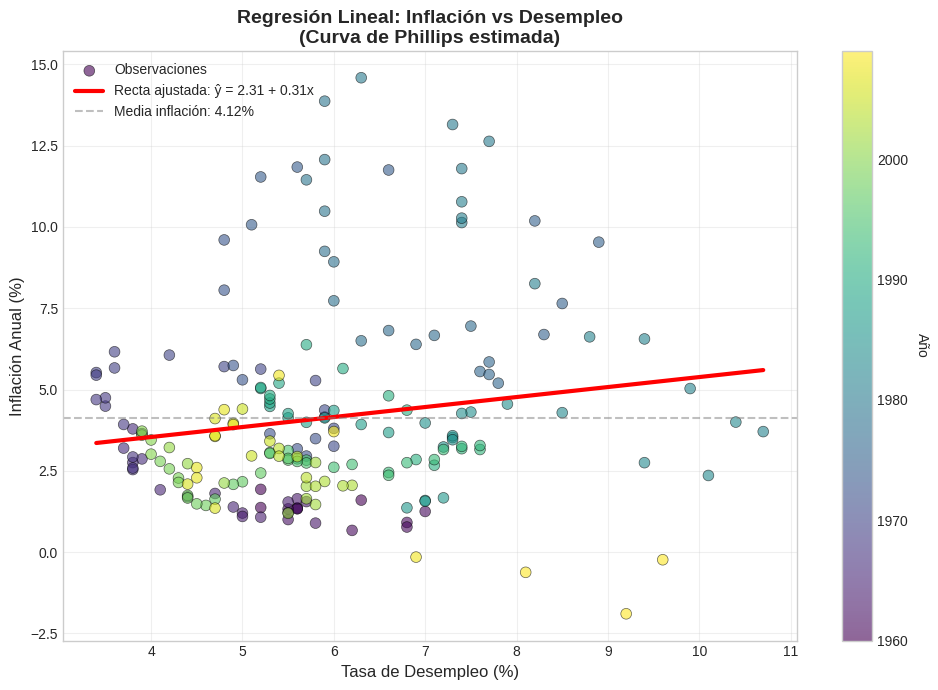


ANÁLISIS DE RESIDUOS (Diagnóstico)
Media de residuos: 0.000000 (debería ser ~0)
Desviación estándar de residuos: 2.9025
Durbin-Watson: 0.0888
  → < 1.5: Autocorrelación positiva fuerte (PROBLEMA)
  → 1.5-2.5: No hay autocorrelación (ideal)
  → > 2.5: Autocorrelación negativa


In [ ]:

# Gráfico con recta ajustada
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot con color según año para mostrar evolución temporal
scatter = ax.scatter(df_clean['unemp'], df_clean['inflacion_anual'],
                    c=df_clean.index.year, cmap='viridis', alpha=0.6, s=60,
                    edgecolors='black', linewidth=0.5, label='Observaciones')

# Recta de regresión
x_line = np.linspace(df_clean['unemp'].min(), df_clean['unemp'].max(), 100)
y_line = beta0 + beta1 * x_line
ax.plot(x_line, y_line, 'r-', linewidth=3, label=f'Recta ajustada: ŷ = {beta0:.2f} + {beta1:.2f}x')

# Línea de media de inflación
ax.axhline(y=df_clean['inflacion_anual'].mean(), color='gray', linestyle='--',
          alpha=0.5, label=f'Media inflación: {df_clean["inflacion_anual"].mean():.2f}%')

# Anotaciones
ax.set_xlabel('Tasa de Desempleo (%)', fontsize=12)
ax.set_ylabel('Inflación Anual (%)', fontsize=12)
ax.set_title('Regresión Lineal: Inflación vs Desempleo\n(Curva de Phillips estimada)',
            fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# Análisis de residuos para detectar problemas
print("\n" + "=" * 70)
print("ANÁLISIS DE RESIDUOS (Diagnóstico)")
print("=" * 70)
residuos = resultados.resid
fitted = resultados.fittedvalues

print(f"Media de residuos: {residuos.mean():.6f} (debería ser ~0)")
print(f"Desviación estándar de residuos: {residuos.std():.4f}")
print(f"Durbin-Watson: {sm.stats.stattools.durbin_watson(residuos):.4f}")
print(f"  → < 1.5: Autocorrelación positiva fuerte (PROBLEMA)")
print(f"  → 1.5-2.5: No hay autocorrelación (ideal)")
print(f"  → > 2.5: Autocorrelación negativa")


## PARTE IV: ANÁLISIS CRÍTICO

*¿La regresión estimada prueba causalidad?*

La regresión lineal estima asociaciones condicionales, no efectos causales.
Para que exista causalidad, necesitamos que se cumplan condiciones estrictas
que en este caso NO se satisfacen.

RAZÓN 1 - ENDOGENEIDAD / VARIABLES OMITIDAS:
PROBLEMA:
Hay variables que afectan simultáneamente a inflación y desempleo,
creando una correlación espuria.

EJEMPLOS DE VARIABLES OMITIDAS:
* Choques de oferta (precios del petróleo): Afectan costos de producción
  (inflación) y empleo (desempleo) simultáneamente
* Política monetaria expansiva: Puede reducir desempleo a corto plazo
  pero aumentar inflación
* Expectativas inflacionarias: Afectan negociaciones salariales y precios
* Productividad: Afecta costos y demanda laboral

CONSECUENCIA:

El coeficiente β₁ captura no solo el efecto del desempleo sobre inflación,
sino también el efecto de todas las variables omitidas correlacionadas
con ambas variables. Esto genera SESGO DE VARIABLES OMITIDAS.

EVIDENCIA EN NUESTROS DATOS:

La correlación positiva (contraintuitiva) sugiere que un tercer factor
(shocks de oferta) está dominando la relación.

---

RAZÓN 2 SIMULTANEIDAD / DOBLE CAUSALIDAD:

PROBLEMA:
¿El desempleo causa inflación, o la inflación causa desempleo?
La relación puede ser bidireccional.

MECANISMOS POSIBLES:
* Desempleo → Inflación (Curva de Phillips): Menos desempleo →
  mayor poder de negociación de trabajadores → salarios ↑ → precios ↑
* Inflación → Desempleo (Efecto Keynes): Inflación inesperada →
  menores salarios reales → mayor demanda de trabajo → menos desempleo
* Inflación → Desempleo (Efecto de Política): Alta inflación →
  contracción monetaria para estabilizar precios → recesión → desempleo

CONSECUENCIA:

La regresión OLS asume que X (desempleo) es exógeno, pero si hay
simultaneidad, entonces X está correlacionado con el error (u),
violando el supuesto de exogeneidad $E[u|X] = 0$.

EVIDENCIA EN NUESTROS DATOS:

El Durbin-Watson de 0.09 sugiere autocorrelación, que puede indicar
problemas de especificación como simultaneidad o variables omitidas.


*¿Qué variables podrían estar omitidas?*

1. SHOCKS DE OFERTA (Supply Shocks)
* Precios del petróleo: Afectan costos de transporte y producción
* Precios de commodities alimenticios: Componente importante del CPI
* Tipo de cambio: Afecta precios de importaciones
* Costos regulatorios: Normativas ambientales, salariales

EFECTO: Generan inflación sin necesidad de bajo desempleo (estanflación)

---

2. EXPECTATIVAS DE INFLACIÓN
* Expectativas adaptativas: Inflación pasada predice inflación futura
* Expectativas racionales: Agentes anticipan política económica
* Anclaje de expectativas: Credibilidad del banco central

EFECTO: Pueden hacer que la Curva de Phillips se desplace, cambiando
la relación desempleo-inflación

---

3. POLÍTICA MONETARIA Y FISCAL
* Tasa de interés de referencia: Afecta demanda agregada
* Crecimiento de la oferta monetaria (M1, M2)
* Déficit fiscal/Gasto público: Estimula demanda agregada
* Deuda pública: Puede generar presión inflacionaria

EFECTO: Política expansiva puede reducir desempleo pero aumentar inflación

---

4. VARIABLES DEL MERCADO LABORAL
* Productividad del trabajo: Afecta costos unitarios laborales
* Rigideces salariales: Impiden ajuste rápido del mercado laboral
* Sindicalización: Poder de negociación de los trabajadores
* Salario mínimo: Piso para negociaciones salariales

EFECTO: Determinan cómo el desempleo se traduce en presión salarial

---

5. VARIABLES EXTERNAS Y GLOBALES
* Crecimiento económico global: Afecta demanda de exportaciones
* Crisis financieras internacionales: Contagio de recesión
* Guerras comerciales: Afectan cadenas de suministro y precios

EFECTO: Factores exógenos que afectan simultáneamente a ambas variables


Aunque exista correlación o un coeficiente significativo, esto no prueba causalidad. Dos razones: (1) variables omitidas (política monetaria, choques de oferta, expectativas, ciclo) y (2) simultaneidad/causalidad inversa (inflación y desempleo se determinan conjuntamente). Por ello, la regresión simple se interpreta como asociación, no como efecto causal.

In [ ]:
# Demostración empírica: ¿Qué pasa si incluimos expectativas de inflación?
# Usaremos la inflación rezagada como proxy de expectativas adaptativas

# Crear variable de expectativas (inflación rezagada 1 año)
df_clean['infl_rezagada'] = df_clean['inflacion_anual'].shift(4)
df_clean['oil_shock_proxy'] = df_clean['inflacion_anual'] - df_clean['inflacion_anual'].shift(1)  # Proxy simple de shock

# Modelo extendido (solo para ilustración, no es el ejercicio)
df_modelo = df_clean[['inflacion_anual', 'unemp', 'infl_rezagada']].dropna()

if len(df_modelo) > 10:
    X_extendido = df_modelo[['unemp', 'infl_rezagada']]
    X_extendido = sm.add_constant(X_extendido)
    y_extendido = df_modelo['inflacion_anual']

    modelo_extendido = sm.OLS(y_extendido, X_extendido).fit()

    print(f"\nComparación de modelos:")
    print(f"Modelo simple (solo desempleo): R² = {r2:.4f}")
    print(f"Modelo extendido (desempleo + expectativas): R² = {modelo_extendido.rsquared:.4f}")
    print(f"\nCoeficientes modelo extendido:")
    print(f"  Desempleo: {modelo_extendido.params['unemp']:.4f} (antes era {beta1:.4f})")
    print(f"  Inflación rezagada: {modelo_extendido.params['infl_rezagada']:.4f}")


Comparación de modelos:
Modelo simple (solo desempleo): R² = 0.0237
Modelo extendido (desempleo + expectativas): R² = 0.6543

Coeficientes modelo extendido:
  Desempleo: -0.6962 (antes era 0.3072)
  Inflación rezagada: 0.9606


Al incluir la inflación rezagada (proxy de expectativas):

R² salta de 2.4% a 65.4% (el modelo ahora sí explica)

El coeficiente del desempleo cambia de +0.31 a -0.70 (ahora tiene el signo correcto según la teoría)

Esto demuestra empíricamente que nuestro modelo original estaba gravemente mal especifica

# Conclusiones:

**Cano Portugal Israel Daniel Arturo**:

La práctica demuestra que la econometría requiere rigor tanto técnico como teórico: si bien construimos variables correctamente y estimamos una regresión estadísticamente significativa entre inflación y desempleo, los resultados revelan una correlación positiva (contraintuitiva) con un $R^2$ de solo $2.4%$, evidenciando que el modelo simple está gravemente mal especificado. El análisis crítico muestra que no existe causalidad probada debido a endogeneidad, simultaneidad y variables omitidas cruciales como expectativas de inflación y shocks de oferta; de hecho, al incluir la inflación rezagada como proxy de expectativas, el $R^2$ salta a $65.4%$ y el coeficiente del desempleo cambia al signo negativo predicho por la teoría, confirmando el sesgo de variables omitidas. Así, vemos de forma central que la significancia estadística no implica relevancia económica ni causalidad, y que un buen modelo econométrico debe fundamentarse en teoría sólida, diagnosticar supuestos rigurosamente y reconocer la inestabilidad temporal de las relaciones macroeconómicas.

**Ramírez Montiel Alejandro**

En esta práctica se construyeron variables macroeconómicas a partir de datos trimestrales: un proxy de consumo nominal combinando consumo real con el nivel de precios, así como tasas anuales (YoY) de inflación y crecimiento real mediante rezagos de cuatro trimestres. Las gráficas mostraron que el consumo nominal puede aumentar aun si el consumo real no crece, porque la inflación eleva el nivel de precios y “infla” las magnitudes nominales. Al analizar inflación y desempleo, la relación lineal global resultó débil y cambiante por décadas, lo que sugiere inestabilidad estructural. La regresión lineal simple de inflación sobre desempleo arrojó un coeficiente estadísticamente significativo pero con muy bajo poder explicativo, además de evidencia de autocorrelación en los residuos; por ello, la regresión no puede interpretarse como causal. Finalmente, al incluir una proxy de expectativas inflacionarias (inflación rezagada), el ajuste mejoró notablemente y el signo del desempleo cambió, reforzando la idea central de que correlación no implica causalidad y que la inferencia económica depende críticamente de la especificación del modelo y de variables omitidas.

**Sandoval Rosas Gustavo Isaac**

Esta práctica nos mostró que la econometría va más allá de ejecutar código: requiere entender qué representan realmente los datos. Al construir variables como consumo nominal, inflación y crecimiento real, aprendimos que los valores nominales pueden aumentar solo por subida de precios, sin que mejore el bienestar de las personas. Al analizar la relación entre inflación y desempleo, una regresión simple dio resultados confusos y con poco poder explicativo, lo que nos llevó a comprender que omitir variables importantes como las expectativas de inflación puede sesgar completamente las conclusiones. La enseñanza central es que un resultado estadístico significativo no basta; para que un modelo sea útil debe estar respaldado por teoría económica, revisar sus supuestos y considerar qué factores clave podrían estar faltando, porque correlación nunca implica causalidad.